# Crossectionnal MRI

## Define current working directory

In [49]:
import os
notebook_dir = os.getcwd()
print("Current notebook directory:", notebook_dir)

Current notebook directory: /mnt/filerc/LREN/PI_DRAGANSKI/abussy/WMH_new/WMH_analyses


## Define all good PR

In [6]:
# Import required libraries
import pandas as pd
import os

# Define file paths
flair_qc_path = os.path.join(notebook_dir, 'CSV/QC_FLAIR_150125.csv')
mpm_qc_path = os.path.join(notebook_dir, 'CSV/QC_MPM_150125.csv')
diff_qc_path = os.path.join(notebook_dir, 'CSV/QC_diffusion_150125.csv')

# Load datasets
flair_qc = pd.read_csv(flair_qc_path)
mpm_qc = pd.read_csv(mpm_qc_path)
diffusion_qc = pd.read_csv(diff_qc_path)

# Create PR variable
flair_qc['PR'] = flair_qc['NAMES FLAIR'].str[1:8]
flair_qc['QC_flair'] = flair_qc['QC']
mpm_qc['PR'] = mpm_qc['Names'].str[1:8]
diffusion_qc['PR'] = diffusion_qc['Names'].str[1:8]
diffusion_qc['QC_diff'] = diffusion_qc['QC']

# Merge QC togethe
flair_mpm_qc = pd.merge(flair_qc[['QC_flair','PR']], mpm_qc[['Names','QC_R1','QC_R2s','QC_MT','PR']], on='PR')
flair_mpm_diffusion_qc = pd.merge(flair_mpm_qc, diffusion_qc[['QC_diff','PR']], on='PR')

# Filter by QC criteria
good_QC = flair_mpm_diffusion_qc[
    (flair_mpm_diffusion_qc['QC_R1'].astype(float) < 2.5) &
    (flair_mpm_diffusion_qc['QC_R2s'].astype(float) < 2.5) &
    (flair_mpm_diffusion_qc['QC_MT'].astype(float) < 2.5) &
    (flair_mpm_diffusion_qc['QC_flair'].astype(float) < 2.5) &
    (flair_mpm_diffusion_qc['QC_diff'].astype(float) < 2.5)
]

# Create table with QC info
flair_mpm_diffusion_qc=flair_mpm_diffusion_qc.astype({'QC_flair': 'category', 'QC_R1': 'category', 'QC_R2s': 'category','QC_MT': 'category','QC_diff': 'category'})
#table_QC=TableOne(flair_mpm_diffusion_qc, columns=['QC_flair', 'QC_R1','QC_R2s','QC_MT','QC_diff'], pval=False)# Create a styled summary table
#table_QC.to_csv(os.path.join(notebook_dir, 'CSV/table_QC.csv'))

good_PR = good_QC['PR'].tolist()

# Print the length of good_PR for verification
print("Number of good PRs:", len(good_PR))


Number of good PRs: 481


## Match with CVR to select PR who have everything

In [10]:
import os
import glob
import pandas as pd
from sklearn.model_selection import train_test_split

# Load csv variable baseline
BL = pd.read_csv(os.path.join(notebook_dir, 'CSV/4AB_var_all_BD16052024_BL.csv'))
F1 = pd.read_csv(os.path.join(notebook_dir, 'CSV/4AB_var_all_BD16052024_F1.csv'))
F2 = pd.read_csv(os.path.join(notebook_dir, 'CSV/4AB_var_all_BD16052024_F2.csv'))
F3 = pd.read_csv(os.path.join(notebook_dir, 'CSV/4AB_var_all_BD16052024_F3.csv'))

# Load PT to colausID
PT_to_colaudID= pd.read_csv( os.path.join(notebook_dir, 'CSV/4AB_CORR_BD18052024.csv'))

# Convert columns to string
BL['pt'] = BL['pt'].astype(str)
F1['pt'] = F1['pt'].astype(str)
F2['pt'] = F2['pt'].astype(str)
F3['pt'] = F3['pt'].astype(str)
PT_to_colaudID['CoLaus_ID'] = PT_to_colaudID['CoLaus_ID'].astype(str)

# Select only rows from BL where variable_A equals 1
PT_to_colaudID_1=PT_to_colaudID[PT_to_colaudID['Family-ID']==1]
PT_to_colaudID_no1=PT_to_colaudID[PT_to_colaudID['Family-ID']!=1]


# Merge the DataFrames on the matching columns
merged_BL_1 = pd.merge(BL, PT_to_colaudID_1, left_on='pt', right_on='CoLaus_ID')
merged_F1_1 = pd.merge(F1, PT_to_colaudID_1, left_on='pt', right_on='CoLaus_ID')
merged_F2_1 = pd.merge(F2, PT_to_colaudID_1, left_on='pt', right_on='CoLaus_ID')
merged_F3_1 = pd.merge(F3, PT_to_colaudID_1, left_on='pt', right_on='CoLaus_ID')

merged_BL_no1 = pd.merge(BL, PT_to_colaudID_no1, left_on='pt', right_on='CoLaus_ID')
merged_F1_no1 = pd.merge(F1, PT_to_colaudID_no1, left_on='pt', right_on='CoLaus_ID')
merged_F2_no1 = pd.merge(F2, PT_to_colaudID_no1, left_on='pt', right_on='CoLaus_ID')
merged_F3_no1 = pd.merge(F3, PT_to_colaudID_no1, left_on='pt', right_on='CoLaus_ID')

# Create PR variable
merged_BL_1['PR'] = 's' + merged_BL_1['SubjectName'].str[:16]
merged_F1_1['PR'] = 's' + merged_F1_1['SubjectName'].str[:16]
merged_F2_1['PR'] = 's' + merged_F2_1['SubjectName'].str[:16]
merged_F3_1['PR'] = 's' + merged_F3_1['SubjectName'].str[:16]

merged_BL_no1['PR'] = 's' + merged_BL_no1['SubjectName'].str[:16]
merged_F1_no1['PR'] = 's' + merged_F1_no1['SubjectName'].str[:16]
merged_F2_no1['PR'] = 's' + merged_F2_no1['SubjectName'].str[:16]
merged_F3_no1['PR'] = 's' + merged_F3_no1['SubjectName'].str[:16]

# Find common PRs
common_PR_BL_F1 = sorted(list(set(merged_BL_1['PR']).intersection(set(merged_F1_1['PR']))))
common_PR_F2_F3 = sorted(list(set(merged_F2_1['PR']).intersection(set(merged_F3_1['PR']))))
common_PR_BL_F1_F2_F3 = sorted(list(set(common_PR_BL_F1).intersection(set(common_PR_F2_F3))))
print(f"Number of common PR names in merged_F1_1 and merged_BL_1: {len(common_PR_BL_F1)}")
print(f"Number of common PR names in merged_F2_1 and merged_F3_1: {len(common_PR_F2_F3)}")
print(f"Number of common PR names across BL, F1, F2, F3: {len(common_PR_BL_F1_F2_F3)}")

common_PR_BL_F1_no1 = sorted(list(set(merged_BL_no1['PR']).intersection(set(merged_F1_no1['PR']))))
common_PR_F2_F3_no1 = sorted(list(set(merged_F2_no1['PR']).intersection(set(merged_F3_no1['PR']))))
common_PR_BL_F1_F2_F3_no1 = sorted(list(set(common_PR_BL_F1_no1).intersection(set(common_PR_F2_F3_no1))))

# Filter common_PR_BL_F1_F2_F3 by checking 2nd to 8th characters against good_PR
common_PR_BL_F1_F2_F3_good_PR = sorted([
    pr for pr in common_PR_BL_F1_F2_F3 if pr[1:8] in good_PR
])

# Update common_PR to also include filtering with pathID_ok
common_PR = common_PR_BL_F1_F2_F3_good_PR

# Print the filtered results
print(f"Number of PRs in common_PR_BL_F1_F2_F3_good_PR: {len(common_PR_BL_F1_F2_F3_good_PR)}")

# Create DataFrame with good PRs
df_common_PR_good = pd.DataFrame(common_PR_BL_F1_F2_F3_good_PR, columns=['PR'])

# Merge the DataFrames on the matching columns
merged_BL_1_common = pd.merge(merged_BL_1, df_common_PR_good, on='PR')
merged_F1_1_common = pd.merge(merged_F1_1, df_common_PR_good, on='PR')
merged_F2_1_common = pd.merge(merged_F2_1, df_common_PR_good, on='PR')
merged_F3_1_common = pd.merge(merged_F3_1, df_common_PR_good, on='PR')

# Verify that the merged files contain only PRs matching good_PR
print(f"Number of PRs in merged_BL_1_common: {len(merged_BL_1_common['PR'].unique())}")
print(f"Number of PRs in merged_F1_1_common: {len(merged_F1_1_common['PR'].unique())}")
print(f"Number of PRs in merged_F2_1_common: {len(merged_F2_1_common['PR'].unique())}")
print(f"Number of PRs in merged_F3_1_common: {len(merged_F3_1_common['PR'].unique())}")



Number of common PR names in merged_F1_1 and merged_BL_1: 249
Number of common PR names in merged_F2_1 and merged_F3_1: 245
Number of common PR names across BL, F1, F2, F3: 244
Number of PRs in common_PR_BL_F1_F2_F3_good_PR: 169
Number of PRs in merged_BL_1_common: 169
Number of PRs in merged_F1_1_common: 169
Number of PRs in merged_F2_1_common: 169
Number of PRs in merged_F3_1_common: 169


## For Fabio

In [19]:
merged_F3_1.to_csv(os.path.join(notebook_dir, 'CSV/merged_F3_1.csv'))
print(merged_F3_1)

,pt,F3sex,F3datexam,F3age,F3cmp,F3hdv,F3chf,F3artm,F3angn,F3miac,...,CoLaus_ID,Family-ID,Follow-up,SubjectName,Age,Unnamed: 6,Gender,StudySubjectID,StudyDate,PR
0,1,1.0,15aug2018,61.900002,0.0,0.0,0.0,0.0,0.0,0.0,...,1,1.0,4.0,PR06239_DB110956^C,66.54,NaN,M,50001-1-4,2023-03-29,sPR06239_DB110956
1,44,0.0,30apr2018,62.500000,0.0,0.0,0.0,0.0,0.0,0.0,...,44,1.0,4.0,PR06351_AB121155^C,67.57,NaN,F,50044-1-4,2023-06-06,sPR06351_AB121155
2,60,0.0,14may2018,70.300003,0.0,0.0,0.0,0.0,0.0,0.0,...,60,1.0,4.0,PR05768_CH110148^C,74.22,NaN,F,50060-01-4,2022-03-31,sPR05768_CH110148
3,103,0.0,15may2018,72.300003,0.0,0.0,0.0,0.0,0.0,0.0,...,103,1.0,4.0,PR05792_MF040246^C,76.20,NaN,F,50103-01-4,2022-04-19,sPR05792_MF040246
4,105,0.0,17-Jul-18,66.699997,0.0,0.0,0.0,0.0,0.0,0.0,...,105,1.0,4.0,PR05741_CH221051^C,70.38,NaN,F,50105-01-4,2022-03-09,sPR05741_CH221051
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241,9355,0.0,05-Nov-18,72.400002,0.0,0.0,0.0,0.0,0.0,0.0,...,9355,1.0,4.0,PR06385_IS260546^C,77.30,NaN,F,60355-1-4,2023-09-13,sPR06385_IS260546
242,9390,0.0,07dec2018,74.900002,0.0,0.0,0.0,0.0,0.0,0.0,...,9390,1.0,4.0,PR06458_NL190144^C,79.84,NaN,F,60390-1-4,2023-11-21,sPR06458_NL190144
243,9402,0.0,04feb2019,62.099998,0.0,0.0,0.0,0.0,0.0,0.0,...,9402,1.0,4.0,PR05879_KH171256^C,65.52,NaN,F,60402-01-4,2022-06-23,sPR05879_KH171256
244,9476,1.0,20feb2019,62.400002,0.0,0.0,0.0,0.0,0.0,0.0,...,9476,1.0,4.0,PR06483_GD121056^C,67.15,NaN,M,60476-1-4,2023-12-06,sPR06483_GD121056


## Define cross-sectionnal data (i.e. all good FLAIR + segmentation)

In [30]:
### cross-sectional from brainlaus
### TO CHECK : new data from which dataset???

PT_to_colaudID = PT_to_colaudID.copy()  # Create a copy of the DataFrame
PT_to_colaudID['PR_short'] = PT_to_colaudID['SubjectName'].str[:7]
merged_PR = pd.merge(good_QC, PT_to_colaudID, left_on='PR', right_on='PR_short')
PR_colaus_cross_sectionnal = merged_PR[merged_PR['Unnamed: 0'] != 'UNKNOWN']
#PR_colaus = PR_colaus[PR_colaus['Unnamed: 0'] != 'NCCR']
#PR_colaus_cross_sectionnal = PR_colaus_cross_sectionnal[PR_colaus_cross_sectionnal['Unnamed: 0'] != 'SACR']
PR_colaus_cross_sectionnal = PR_colaus_cross_sectionnal.copy()  # Create a copy of the DataFrame
PR_colaus_cross_sectionnal['PR'] = 's' + PR_colaus_cross_sectionnal['SubjectName'].str[:16]
len(PR_colaus_cross_sectionnal)

441

## Process these specific scans using common_PR - cross-sectional (DO NOT RERUN)

In [51]:
import os
import nibabel as nib
import glob
import numpy as np
from scipy.ndimage import binary_dilation, binary_erosion, binary_fill_holes
import pickle
from tqdm import tqdm
from multiprocessing import Pool, cpu_count

def load_nifti_data(file_path):
    if isinstance(file_path, list):
        file_path = file_path[0] if file_path else None  # Select the first file if the list is non-empty
    try:
        data = nib.load(file_path).get_fdata() if file_path else None
        return data
    except Exception as e:
        print(f"Error loading NIfTI file {file_path}: {e}")
        return None


def save_checkpoint(data, filename):
    temp_filename = filename + '.tmp'
    with open(temp_filename, 'wb') as f:
        pickle.dump(data, f)
    os.replace(temp_filename, filename)

def load_checkpoint(filename):
    if os.path.exists(filename):
        try:
            with open(filename, 'rb') as f:
                return pickle.load(f)
        except (pickle.UnpicklingError, EOFError) as e:
            print(f"Error loading checkpoint {filename}: {e}")
            return None
    return None

def save_batch(batch_data, batch_index, batch_type='masks'):
    batch_folder = dictionnary_dir
    batch_file = os.path.join(batch_folder, f'{batch_type}_batch_cross_sectionnal_{batch_index}.pkl')
    with open(batch_file, 'wb') as f:
        pickle.dump(batch_data, f)

def apply_mask(data, mask):
    if data is not None and mask is not None:
        return data * mask
    return data

def save_cleaned_wmh_data(wmh_data, original_file_path):
    if wmh_data is not None:
        # Load the original WMH NIfTI to get the affine matrix
        original_nifti = nib.load(original_file_path)
        affine_matrix = original_nifti.affine  # Extract affine matrix
        
        # Create the output filename by adding 'cleaned' to the original filename
        cleaned_filename = original_file_path.replace('.nii.gz', '_cleaned.nii.gz')
        
        # Create a NIfTI image object from the cleaned data using the original affine matrix
        cleaned_nifti = nib.Nifti1Image(wmh_data, affine_matrix)
        
        # Save the cleaned data
        nib.save(cleaned_nifti, cleaned_filename)
        print(f"Saved cleaned WMH data to {cleaned_filename}")
    else:
        print("No cleaned WMH data to save.")

def process_subject(pr_tuple):
    pr, pr_short = pr_tuple
    subject_data = {}

    # Define paths based on the updated structure
    wm_file_path = glob.glob(os.path.join(dir_path, 'MPRAGE', pr, f'{pr}*WM.*'))
    wmh_file_path = glob.glob(os.path.join(dir_path, 'FLAIR', pr, f'whitenet_FLAIR_WMH_sanlm_m{pr}*_in_MPRAGE_masked_in_MPM.nii.gz'))
    csf_file_path = glob.glob(os.path.join(dir_path, 'MPRAGE', pr, f'{pr}*CSF.*'))

    wm_data = load_nifti_data(wm_file_path)
    wmh_data = load_nifti_data(wmh_file_path)
    csf_data = load_nifti_data(csf_file_path)

    if wm_data is not None:
        subject_data['WM'] = wm_data
    if csf_data is not None:
        subject_data['CSF'] = csf_data

    if wm_data is not None and wmh_data is not None:
        wmh_data = np.where((wmh_data == 1) & (wm_data == 0), 0, wmh_data)
        nawm_data = np.logical_and(wm_data == 1, wmh_data == 0).astype(np.uint8)
        subject_data['NAWM'] = nawm_data
        subject_data['WMH'] = wmh_data
    else:
        nawm_data = None

    if wmh_data is not None:
        wmh_dilated = binary_dilation(wmh_data, iterations=1)
        wmh_inverted = np.logical_not(wmh_data).astype(np.uint8)
        layer_1 = wmh_dilated * wmh_inverted

        layers = [apply_mask(layer_1, nawm_data)] + [
            apply_mask(np.logical_xor(binary_dilation(wmh_data, iterations=i+1), binary_dilation(wmh_data, iterations=i)), nawm_data)
            for i in range(1, 5)
        ]
        subject_data['Layers'] = layers

        # Define Inner Layers
        inner_layer_1 = np.logical_xor(wmh_data, binary_erosion(wmh_data, iterations=1))
        inner_layer_2 = binary_erosion(wmh_data, iterations=1).astype(np.uint8) - binary_erosion(wmh_data, iterations=2).astype(np.uint8)
        
        subject_data['InnerLayers'] = [inner_layer_1, inner_layer_2]

        wmh_center_mask = binary_erosion(wmh_data, iterations=2)
        subject_data['WMH_center'] = wmh_center_mask

        # Now save the cleaned WMH data with 'cleaned' added to the filename
        save_cleaned_wmh_data(wmh_data, wmh_file_path[0])  # Save using the original file path

    if nawm_data is not None:
        wmh_dilated_mask = binary_dilation(wmh_data, iterations=5)
        wmh_inverted_mask = np.logical_not(wmh_dilated_mask).astype(np.uint8)
        wm_left_mask = nawm_data * wmh_inverted_mask
        subject_data['WM_left'] = wm_left_mask

    if csf_data is not None and wm_data is not None:
        csf_dilated_mask = binary_dilation(csf_data, iterations=8)
        combined_wm_csf = np.logical_or(wm_data, csf_dilated_mask).astype(np.uint8)

        # Fill holes in the combined WM and CSF mask
        combined_filled = binary_fill_holes(combined_wm_csf).astype(np.uint8)

        # Erode the filled combined mask
        combined_eroded = binary_erosion(combined_filled, iterations=2)

        # Define SWM mask
        swm_mask = combined_filled * np.logical_not(combined_eroded).astype(np.uint8)
        subject_data['SWM'] = swm_mask

        # Define PVWM mask
        csf_dilated_mask = binary_dilation(csf_data, iterations=8)
        csf_inverted_mask = np.logical_not(csf_data).astype(np.uint8)
        pvwm_mask = csf_dilated_mask * csf_inverted_mask * wm_data
        subject_data['PVWM'] = pvwm_mask      
        
    if all(mask in subject_data for mask in ['WM', 'PVWM', 'SWM', 'CSF']):
        dwm_mask = wm_data * np.logical_not(subject_data['PVWM']) * np.logical_not(subject_data['SWM']) * np.logical_not(csf_data).astype(np.uint8)
        subject_data['DWM'] = dwm_mask

    if 'WMH' in subject_data:
        subject_data['WMH_DWM'] = np.logical_and(subject_data['WMH'], subject_data.get('DWM', 0)).astype(np.uint8)
        subject_data['WMH_SWM'] = np.logical_and(subject_data['WMH'], subject_data.get('SWM', 0)).astype(np.uint8)
        subject_data['WMH_PVWM'] = np.logical_and(subject_data['WMH'], subject_data.get('PVWM', 0)).astype(np.uint8)

    if 'NAWM' in subject_data:
        subject_data['NAWM_SWM'] = nawm_data * subject_data.get('SWM', 0)
        subject_data['NAWM_DWM'] = nawm_data * subject_data.get('DWM', 0)
        subject_data['NAWM_PVWM'] = nawm_data * subject_data.get('PVWM', 0)

    return pr, subject_data

def load_metrics(pr):
    subject_metrics = {}
    for data_type, file_pattern in data_types.items():
        metric_file_pattern = os.path.join(mpm_path, pr, file_pattern)
        metric_files = glob.glob(metric_file_pattern)
        
        for metric_file_path in metric_files:
            metric_data = load_nifti_data(metric_file_path)
            if metric_data is not None:
                if data_type not in subject_metrics:
                    subject_metrics[data_type] = {}
                subject_metrics[data_type][pr] = metric_data
    return subject_metrics

def calculate_mean_sd_metrics(data_type, metric_data_dict, mask_dict):
    mean_metrics = {key: {} for key in mask_dict.keys() if key not in ['WM', 'CSF']}
    sd_metrics = {key: {} for key in mask_dict.keys() if key not in ['WM', 'CSF']}
    for subject, metric_data in metric_data_dict.items():
        for mask_key in mean_metrics.keys():
            if mask_key in mask_dict and subject in mask_dict[mask_key]:
                mask_data = mask_dict[mask_key][subject]
                masked_metric_data = metric_data[mask_data == 1]
                if masked_metric_data.size > 0:
                    mean_value = np.mean(masked_metric_data)
                    sd_value = np.std(masked_metric_data)
                else:
                    mean_value = np.nan
                    sd_value = np.nan
                mean_metrics[mask_key][subject] = mean_value
                sd_metrics[mask_key][subject] = sd_value
    return data_type, mean_metrics, sd_metrics

def process_and_save_batch(pr_batch, batch_index):
    # Initialize the nifti_masks dictionary for the batch
    batch_masks = {key: {} for key in [
        'WM', 'WMH', 'CSF', 'NAWM', 'Layer1', 'Layer2', 'Layer3', 'Layer4', 'Layer5',
        'InnerLayer1', 'InnerLayer2', 'WMH_center', 'WM_left', 'PVWM', 'SWM', 'DWM', 
        'WMH_DWM', 'WMH_SWM', 'WMH_PVWM', 'NAWM_SWM', 'NAWM_DWM', 'NAWM_PVWM'
    ]}

    # Load masks
    with Pool(cpu_count()) as pool:
        results = pool.map(process_subject, pr_batch)
    
    for pr, subject_data in results:
        for key, value in subject_data.items():
            if key == 'Layers':
                for i, layer in enumerate(value):
                    layer_key = f'Layer{i+1}'
                    if pr not in batch_masks[layer_key]:
                        batch_masks[layer_key][pr] = layer
            elif key == 'InnerLayers':
                for i, inner_layer in enumerate(value):
                    inner_layer_key = f'InnerLayer{i+1}'
                    if pr not in batch_masks[inner_layer_key]:
                        batch_masks[inner_layer_key][pr] = inner_layer
            else:
                batch_masks[key][pr] = value
    # Save the batch of masks
    save_batch(batch_masks, batch_index, batch_type='masks')

    # Load metrics and calculate means and standard deviations
    batch_metrics = {data_type: {} for data_type in data_types}
    for pr in [pr for pr, pr_short in pr_batch]:
        subject_metrics = load_metrics(pr)
        for data_type, metrics in subject_metrics.items():
            batch_metrics[data_type].update(metrics)
    save_batch(batch_metrics, batch_index, batch_type='metrics')

    # Calculate mean and standard deviation metrics
    mean_sd_metrics_results = []
    for data_type in data_types:
        if data_type in batch_metrics:
            data_type_result = calculate_mean_sd_metrics(data_type, batch_metrics[data_type], batch_masks)
            mean_sd_metrics_results.append(data_type_result)

    output_dictionary_mean = {f'Mean_Metrics_In_{data_type}': {} for data_type in data_types}
    output_dictionary_sd = {f'SD_Metrics_In_{data_type}': {} for data_type in data_types}
    for key, mean_value, sd_value in mean_sd_metrics_results:
        output_dictionary_mean[f'Mean_Metrics_In_{key}'] = mean_value
        output_dictionary_sd[f'SD_Metrics_In_{key}'] = sd_value

    save_checkpoint(output_dictionary_mean, os.path.join(dictionnary_dir, f'metrics_cross_sectional_mean_batch_{batch_index}.pkl'))


common_PR_cross_sectionnal=PR_colaus_cross_sectionnal['PR']

# Main processing loop
dir_path = '/mnt/filerc/LREN/PI_DRAGANSKI/abussy/WMH_new/'
mpm_path = '/mnt/filerc/LREN/PI_DRAGANSKI/abussy/WMH_new/MPM/'
dictionnary_dir='/mnt/HDD1/USERS_DATAS/aurelie/Dictionnaries_cross/'
batch_size = 5
PR_short_cross_sectionnal = [pr[1:8] for pr in common_PR_cross_sectionnal]


# Define data types and their corresponding file patterns
data_types = {
    'MT': 's*MT.nii',
    'R1': 's*R1.nii',
    'R2*': 's*R2s_OLS.nii',
    'ISOVF': '*data_aligned_FIT_ISOVF_in_MPM.nii.gz',
    'ICVF': '*data_aligned_FIT_ICVF_in_MPM.nii.gz',
    'OD': '*data_aligned_FIT_OD_in_MPM.nii.gz',
    'FA': '*data_aligned_unwarped_FA_in_MPM.nii.gz',
    'MD': '*data_aligned_unwarped_MD_in_MPM.nii.gz',
    'g-ratio': '*MT_g_ratio.nii'
}

#common_PR = ["sPR05710_JD190636", "sPR05714_NP091046","sPR05719_PG220250"]  # Replace with your actual subject list
    
batches = [list(zip(common_PR_cross_sectionnal[i:i + batch_size], PR_short_cross_sectionnal[i:i + batch_size])) for i in range(0, len(common_PR_cross_sectionnal), batch_size)]

# Process subjects in batches
for batch_index, batch in enumerate(tqdm(batches, desc='Processing batches')):
    process_and_save_batch(batch, batch_index)

Processing batches:   0%|                                                                                                                                              | 0/89 [00:00<?, ?it/s]

Saved cleaned WMH data to /mnt/filerc/LREN/PI_DRAGANSKI/abussy/WMH_new/FLAIR/sPR05711_SB030899/whitenet_FLAIR_WMH_sanlm_msPR05711_SB030899-0003-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz
Saved cleaned WMH data to /mnt/filerc/LREN/PI_DRAGANSKI/abussy/WMH_new/FLAIR/sPR05710_JD190636/whitenet_FLAIR_WMH_sanlm_msPR05710_JD190636-0003-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz
Saved cleaned WMH data to /mnt/filerc/LREN/PI_DRAGANSKI/abussy/WMH_new/FLAIR/sPR05713_SD101257/whitenet_FLAIR_WMH_sanlm_msPR05713_SD101257-0012-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz
Saved cleaned WMH data to /mnt/filerc/LREN/PI_DRAGANSKI/abussy/WMH_new/FLAIR/sPR05715_AL100858/whitenet_FLAIR_WMH_sanlm_msPR05715_AL100858-0012-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz
Saved cleaned WMH data to /mnt/filerc/LREN/PI_DRAGANSKI/abussy/WMH_new/FLAIR/sPR05714_NP091046/whitenet_FLAIR_WMH_sanlm_msPR05714_NP091046-0003-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz


Processing batches:   1%|█▍                                                                                                                                 | 1/89 [02:02<2:59:21, 122.29s/it]

Saved cleaned WMH data to /mnt/filerc/LREN/PI_DRAGANSKI/abussy/WMH_new/FLAIR/sPR05717_JB170499/whitenet_FLAIR_WMH_sanlm_msPR05717_JB170499-0003-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz
Saved cleaned WMH data to /mnt/filerc/LREN/PI_DRAGANSKI/abussy/WMH_new/FLAIR/sPR05723_MC300402/whitenet_FLAIR_WMH_sanlm_msPR05723_MC300402-0003-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz
Saved cleaned WMH data to /mnt/filerc/LREN/PI_DRAGANSKI/abussy/WMH_new/FLAIR/sPR05719_PG220250/whitenet_FLAIR_WMH_sanlm_msPR05719_PG220250-0004-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz
Saved cleaned WMH data to /mnt/filerc/LREN/PI_DRAGANSKI/abussy/WMH_new/FLAIR/sPR05720_MA231199/whitenet_FLAIR_WMH_sanlm_msPR05720_MA231199-0012-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz
Saved cleaned WMH data to /mnt/filerc/LREN/PI_DRAGANSKI/abussy/WMH_new/FLAIR/sPR05716_DB130593/whitenet_FLAIR_WMH_sanlm_msPR05716_DB130593-0003-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz


Processing batches:   2%|██▉                                                                                                                                | 2/89 [03:41<2:37:23, 108.55s/it]

...

Processing batches:  98%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████   | 87/89 [2:31:52<03:25, 102.93s/it]

Saved cleaned WMH data to /mnt/filerc/LREN/PI_DRAGANSKI/abussy/WMH_new/FLAIR/sPR06691_EL060251/whitenet_FLAIR_WMH_sanlm_msPR06691_EL060251-0003-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz
Saved cleaned WMH data to /mnt/filerc/LREN/PI_DRAGANSKI/abussy/WMH_new/FLAIR/sPR06699_HG110604/whitenet_FLAIR_WMH_sanlm_msPR06699_HG110604-0003-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz
Saved cleaned WMH data to /mnt/filerc/LREN/PI_DRAGANSKI/abussy/WMH_new/FLAIR/sPR06700_DC110455/whitenet_FLAIR_WMH_sanlm_msPR06700_DC110455-0003-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz
Saved cleaned WMH data to /mnt/filerc/LREN/PI_DRAGANSKI/abussy/WMH_new/FLAIR/sPR06694_JK210857/whitenet_FLAIR_WMH_sanlm_msPR06694_JK210857-0003-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz
Saved cleaned WMH data to /mnt/filerc/LREN/PI_DRAGANSKI/abussy/WMH_new/FLAIR/sPR06701_CC300556/whitenet_FLAIR_WMH_sanlm_msPR06701_CC300556-0003-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz


Processing batches:  99%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌ | 88/89 [2:33:36<01:43, 103.26s/it]

Saved cleaned WMH data to /mnt/filerc/LREN/PI_DRAGANSKI/abussy/WMH_new/FLAIR/sPR06703_NF170556/whitenet_FLAIR_WMH_sanlm_msPR06703_NF170556-0003-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz


Processing batches: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 89/89 [2:34:19<00:00, 104.04s/it]


## Load to avoid rerunning cross-sectionnal

In [52]:
import pickle
import os
import glob

def load_saved_data(batch_index, batch_type='masks'):
    batch_folder = '/mnt/HDD1/USERS_DATAS/aurelie/Dictionnaries_cross/'
    batch_file = os.path.join(batch_folder, f'{batch_type}_batch_{batch_index}.pkl')
    
    if os.path.exists(batch_file):
        try:
            with open(batch_file, 'rb') as f:
                data = pickle.load(f)
                #print(f"Successfully loaded {batch_type} data for batch {batch_index}")
                return data
        except (pickle.UnpicklingError, EOFError) as e:
            print(f"Error loading {batch_type} data for batch {batch_index}: {e}")
            return None
    else:
        print(f"No saved data found for batch {batch_index} and type {batch_type}.")
        return None

def load_all_batches(start_batch, end_batch, batch_type='masks'):
    all_batches = []

    for batch_index in range(start_batch, end_batch + 1):
        batch_data = load_saved_data(batch_index, batch_type)
        if batch_data:
            all_batches.append(batch_data)
    
    return all_batches

def merge_dictionaries(all_batches):
    combined_data = {}

    for batch_data in all_batches:
        for metric_key, regions_data in batch_data.items():
            if metric_key not in combined_data:
                combined_data[metric_key] = {}
            
            for region_key, pr_values in regions_data.items():
                if region_key not in combined_data[metric_key]:
                    combined_data[metric_key][region_key] = {}

                for pr_key, value in pr_values.items():
                    if pr_key in combined_data[metric_key][region_key]:
                        combined_data[metric_key][region_key][pr_key].append(value)
                    else:
                        combined_data[metric_key][region_key][pr_key] = [value]

    return combined_data

# Example usage:
# Load all mean and SD batches from 0 to 31
all_mean_batches = load_all_batches(0, 88, batch_type='metrics_cross_sectional_mean')

# Merge all the loaded batches into combined dictionaries
combined_mean_metrics_data_cross_sectionnal = merge_dictionaries(all_mean_batches)

len(combined_mean_metrics_data_cross_sectionnal['Mean_Metrics_In_MT']['WMH'])

437

## Boxplots SWM PVWM DWM

[8.19187418e-110 1.62696321e-120 1.59442049e-124]
[2.37175744e-107 2.29459808e-120 4.37190605e-125]
[2.53936552e-102 7.37091220e-115 1.06962998e-117]
[6.42509296e-81 4.40868382e-66 6.50077199e-49]
[1.09543035e-100 2.85022497e-116 4.57603086e-125]
[2.03371794e-82 2.95485723e-01 1.47426350e-11]
[5.39565083e-031 1.74850126e-103 1.90323079e-113]
[3.16442763e-093 3.97601784e-109 3.30322964e-109]
[6.74354340e-04 2.94459387e-10 4.67723087e-21]


/tmp/ipykernel_370962/3007872820.py:186: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=13)


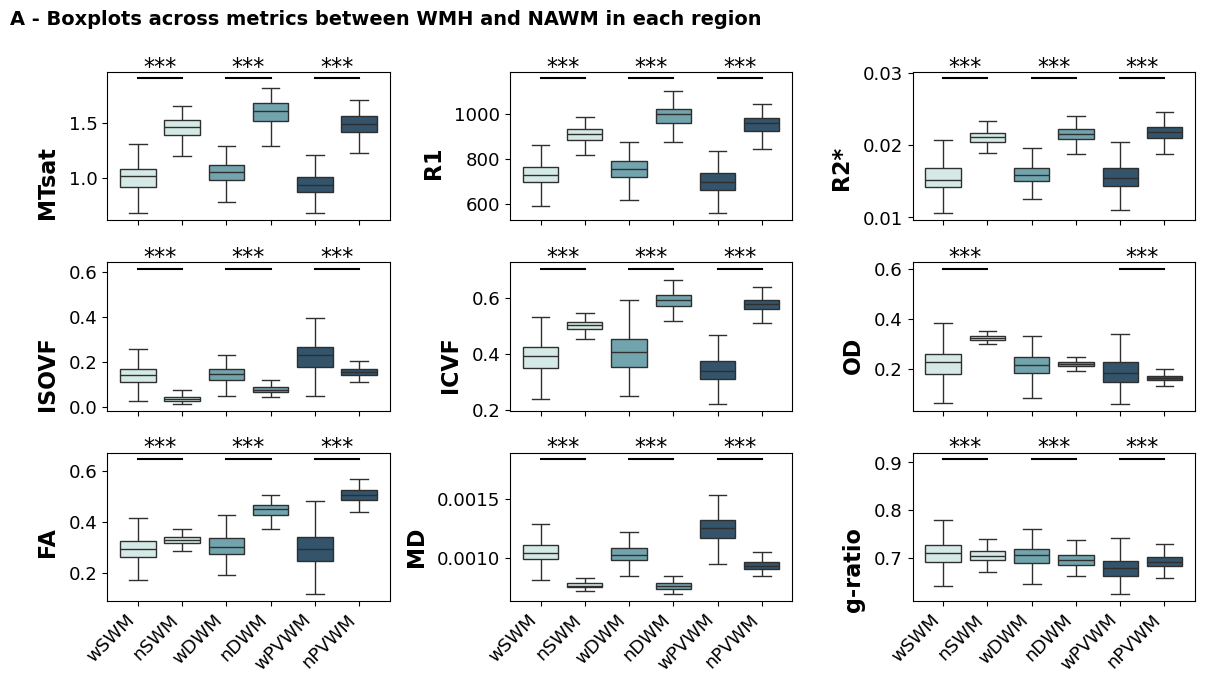

In [54]:
import os
import pickle
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

def load_checkpoint(filename):
    if os.path.exists(filename):
        try:
            with open(filename, 'rb') as f:
                return pickle.load(f)
        except (pickle.UnpicklingError, EOFError) as e:
            print(f"Error loading checkpoint {filename}: {e}")
            return None
    return None

# Path to the directory where the output dictionaries are saved
batch_folder = '/mnt/HDD1/USERS_DATAS/aurelie/Dictionnaries_cross/'

# Load all mean metric batches
mean_batch_files = glob.glob(os.path.join(batch_folder, 'metrics_cross_sectional_mean*.pkl'))

mean_metrics_data = {
    'WMH_DWM': {},
    'NAWM_DWM': {},
    'WMH_PVWM': {},
    'NAWM_PVWM': {},
    'WMH_SWM': {},
    'NAWM_SWM': {}
}

# Extract mean metrics for each category from each batch
for batch_file in mean_batch_files:
    output_dictionary = load_checkpoint(batch_file)
    if output_dictionary:
        for key in output_dictionary.keys():
            metric = key.replace('Mean_Metrics_In_', '')
            if 'WMH_DWM' in output_dictionary[key]:
                if metric not in mean_metrics_data['WMH_DWM']:
                    mean_metrics_data['WMH_DWM'][metric] = {}
                mean_metrics_data['WMH_DWM'][metric].update(output_dictionary[key]['WMH_DWM'])
            if 'NAWM_DWM' in output_dictionary[key]:
                if metric not in mean_metrics_data['NAWM_DWM']:
                    mean_metrics_data['NAWM_DWM'][metric] = {}
                mean_metrics_data['NAWM_DWM'][metric].update(output_dictionary[key]['NAWM_DWM'])
            if 'WMH_PVWM' in output_dictionary[key]:
                if metric not in mean_metrics_data['WMH_PVWM']:
                    mean_metrics_data['WMH_PVWM'][metric] = {}
                mean_metrics_data['WMH_PVWM'][metric].update(output_dictionary[key]['WMH_PVWM'])
            if 'NAWM_PVWM' in output_dictionary[key]:
                if metric not in mean_metrics_data['NAWM_PVWM']:
                    mean_metrics_data['NAWM_PVWM'][metric] = {}
                mean_metrics_data['NAWM_PVWM'][metric].update(output_dictionary[key]['NAWM_PVWM'])
            if 'WMH_SWM' in output_dictionary[key]:
                if metric not in mean_metrics_data['WMH_SWM']:
                    mean_metrics_data['WMH_SWM'][metric] = {}
                mean_metrics_data['WMH_SWM'][metric].update(output_dictionary[key]['WMH_SWM'])
            if 'NAWM_SWM' in output_dictionary[key]:
                if metric not in mean_metrics_data['NAWM_SWM']:
                    mean_metrics_data['NAWM_SWM'][metric] = {}
                mean_metrics_data['NAWM_SWM'][metric].update(output_dictionary[key]['NAWM_SWM'])

# Define metrics to plot
metrics_to_plot = list(mean_metrics_data['WMH_DWM'].keys())

y_axis_captions = ['MTsat', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'FA', 'MD', 'g-ratio']  # Customize these captions as needed


# Define pairwise comparisons
comparisons_to_make = [
    ('wSWM', 'nSWM'), 
    ('wDWM', 'nDWM'), 
    ('wPVWM', 'nPVWM')
]

# Check if there are any metrics to plot
if not metrics_to_plot:
    print("No metrics to plot.")
else:
    # Plotting settings
    num_metrics = len(metrics_to_plot)
    rows = (num_metrics + 2) // 3  # Calculate number of rows needed
    if rows == 0:
        rows = 1
    fig, axes = plt.subplots(rows, 3, figsize=(12, 2 * rows), sharey=False, sharex=True)

    # Flatten axes to handle cases where there are fewer than 3 metrics
    axes = axes.flatten()

    # Define color palette with provided colors
    custom_palette = {
        'wDWM': '#68abb8',  # Medium Teal
        'nDWM': '#68abb8',  # Medium Teal
        'wPVWM':'#2a5674',   # Dark Teal
        'nPVWM': '#2a5674',   # Dark Teal
        'wSWM':  '#d1eeea',  # Light Teal
        'nSWM': '#d1eeea',  # Light Teal
    }

    def add_stat_annotation(ax, x1, x2, y, text):
        ax.plot([x1, x2], [y, y], lw=1.5, color='black')
        ax.text((x1 + x2) * 0.5, y, text, ha='center', va='bottom', color='black', fontsize=16)

    # Define the exact order of the groups on the x-axis
    group_order = ['wSWM', 'nSWM', 'wDWM', 'nDWM', 'wPVWM', 'nPVWM']

    # Loop through metrics and create boxplots
    for i, (metric, caption) in enumerate(zip(metrics_to_plot[:rows*3], y_axis_captions)):  # Only plot the first 12 metrics

        ax = axes[i]
        
        # Gather data for current metric
        metric_data = {
            'wSWM': np.array(list(mean_metrics_data['WMH_SWM'][metric].values())),
            'nSWM': np.array(list(mean_metrics_data['NAWM_SWM'][metric].values())),
            'wDWM': np.array(list(mean_metrics_data['WMH_DWM'][metric].values())),
            'nDWM': np.array(list(mean_metrics_data['NAWM_DWM'][metric].values())),
            'wPVWM': np.array(list(mean_metrics_data['WMH_PVWM'][metric].values())),
            'nPVWM': np.array(list(mean_metrics_data['NAWM_PVWM'][metric].values()))
        }
        
        # Remove NaN values from each group
        for key in metric_data:
            metric_data[key] = metric_data[key][~np.isnan(metric_data[key])]
        
        # Prepare data for boxplot (ensure order SWM, DWM, PVWM)
        data = pd.DataFrame({
            'Metric': np.concatenate([metric_data[group] for group in group_order]),
            'Group': np.concatenate([[group] * len(metric_data[group]) for group in group_order])
        })
        
        # Plot boxplot with individual data points
        sns.boxplot(x='Group', y='Metric', data=data, ax=ax, hue='Group', palette=custom_palette, dodge=False, showfliers=False, legend=False)

        # Remove background horizontal grid lines
        ax.yaxis.grid(False)
        
        # Perform pairwise statistical tests
        p_values = []
        for group1, group2 in comparisons_to_make:
            if len(metric_data[group1]) > 0 and len(metric_data[group2]) > 0:
                _, p_value = mannwhitneyu(metric_data[group1], metric_data[group2])
                p_values.append(p_value)
            else:
                p_values.append(1)  # If either group is empty, set p-value to 1 (no significance)

        # FDR correction
        _, corrected_p_values, _, _ = multipletests(p_values, method='fdr_bh')
        print(corrected_p_values)
        # Annotate plot with significance levels
        y_max = data['Metric'].max() * 1.05
        for (group1, group2), p_value in zip(comparisons_to_make, corrected_p_values):
            group1_idx = group_order.index(group1)
            group2_idx = group_order.index(group2)
            if p_value < 0.001:
                add_stat_annotation(ax, group1_idx, group2_idx, y_max, '***')
            elif p_value < 0.01:
                add_stat_annotation(ax, group1_idx, group2_idx, y_max, '**')
            elif p_value < 0.05:
                add_stat_annotation(ax, group1_idx, group2_idx, y_max, '*')
            #y_max += 0.05 * y_max  # Increment y position for next annotation

        # Set y-axis title to metric name and increase font size
        ax.set_ylabel(caption, fontsize=16, labelpad=15, fontweight='bold', verticalalignment='center', horizontalalignment='right') 
        #ax.set_yticklabels(fontsize=14)
        ax.tick_params(axis='y', labelsize=13)
        # Remove plot title
        ax.set_title('')
        
        # Remove x-axis label for better layout
        ax.set_xlabel('')

    # Remove extra subplots if there are any
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # Adjust layout and display the plot
    plt.tight_layout()

    # Rotate X-axis labels for the bottom row only
    for ax in axes[-3:]:  # Last 3 axes (bottom row)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=13)
        
    # Add a title to the entire plot (aligned to top-left with boxplots)
    plt.suptitle('A - Boxplots across metrics between WMH and NAWM in each region', fontsize=14, fontweight='bold', y=1.05, ha='left', x=0)

    # Save the plot
    plot_path = os.path.join(notebook_dir, f'Figures/Boxplot_WMH_NAWM_PVWM_DWM_SWM_cross_sectionnal.png')
    plt.savefig(plot_path, bbox_inches='tight')

    # Show the plot
    plt.show()
